# Taller 01 · Parte 0 — El modelo base y la distribución del siguiente token

GPT-2 en tu propia máquina, extraemos un paso hacia adelante y miramos la lista completa de probabilidades que un modelo de lenguaje calcula antes de escribir cada palabra. Todo lo demás del taller (temperatura, top-p, top-k, esfuerzo de razonamiento) son formas de *elegir* dentro de esa lista.


## 0. Preparación
Cargamos GPT-2 (openai-community/gpt2, la fila base_local de la tabla semestral) y fijamos la semilla. La línea reemplazar_partes borra del archivo crudo las filas de la Parte 0 de una corrida anterior, para que puedas re-ejecutar el cuaderno sin duplicar filas.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from taller_01_miguel_alvarez import tallerlib as tl

SEMILLA = 7
tl.DIR_FIGURAS.mkdir(exist_ok=True)
tl.DIR_RESULTADOS.mkdir(exist_ok=True)

tok, model = tl.cargar_gpt2()
n_parametros = sum(p.numel() for p in model.parameters())
print(f"Modelo: {tl.GPT2_ID}")
print(f"Parámetros: {n_parametros / 1e6:.0f} M   |   arquitectura: {model.config.architectures}")
print("Versiones:", tl.versiones())

borradas = tl.reemplazar_partes({"0a", "0b", "0c"})
print(f"Filas antiguas de la Parte 0 eliminadas de resultados.csv: {borradas}")

/Users/miguelestebanalvarez/Posgrado Maestría Inteligencia Artificial/1er Semestre/IA Generativa y Agentes/Talleres/taller-01-miguel-alvarez/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Loading weights: 100%|██████████| 148/148 [00:00<00:00, 35338.55it/s]

Modelo: openai-community/gpt2
Parámetros: 124 M   |   arquitectura: ['GPT2LMHeadModel']
Versiones: {'torch': '2.14.0', 'transformers': '5.17.0', 'numpy': '2.5.3'}
Filas antiguas de la Parte 0 eliminadas de resultados.csv: 12


## 0.a — La distribución del siguiente token

### Tres ideas, con números pequeños
1. **Logits**: para cada uno de los ~50 000 tokens posibles, el modelo da un número (puede ser negativo). Mayor = más plausible. No son probabilidades todavía.
2. **Softmax**: convierte los logits en probabilidades que suman 1.
3. **Temperatura T**: antes del softmax se dividen los logits entre T. T < 1 *afila* la distribución (el favorito gana masa); T > 1 la *aplana* (los demás ganan masa). Con T → 0 solo queda el máximo (argmax).

**Ejemplo con tres tokens** (logits 2, 1, 0): la celda siguiente calcula qué pasa con T = 0.5, 1 y 2.

Dos medidas que pide el taller:
- **Entropía en bits**: H = −Σ p·log2(p). 0 bits = el modelo está seguro de un solo token; más bits = más dudas.
- **Tamaño del núcleo al 90 %**: cuántos tokens, de mayor a menor probabilidad, hacen falta para acumular el 90 % de la masa. Es exactamente top_p = 0.9 *medido*: no es una constante, depende del prefijo y de T.

In [2]:
def softmax_T(logits, T=1.0):
    """softmax(logits / T), con el truco de restar el máximo para que no desborde."""
    z = np.asarray(logits, dtype=np.float64) / T
    z = z - z.max()          # no cambia el resultado, evita exp() enormes
    e = np.exp(z)
    return e / e.sum()


def entropia_bits(p):
    p = p[p > 0]             # 0 * log(0) se toma como 0
    return float(-(p * np.log2(p)).sum())


def tamano_nucleo(p, masa=0.9):
    """Cuántos tokens (ordenados de mayor a menor) acumulan `masa`."""
    acumulada = np.cumsum(np.sort(p)[::-1])
    return int(np.searchsorted(acumulada, masa - 1e-12, side="left") + 1)


ejemplo = np.array([2.0, 1.0, 0.0])
for T in (0.5, 1.0, 2.0):
    p = softmax_T(ejemplo, T)
    print(f"T={T:<3}  p = {np.round(p, 3)}   entropía = {entropia_bits(p):.2f} bits   núcleo 90 % = {tamano_nucleo(p)} token(s)")

T=0.5  p = [0.867 0.117 0.016]   entropía = 0.64 bits   núcleo 90 % = 2 token(s)
T=1.0  p = [0.665 0.245 0.09 ]   entropía = 1.20 bits   núcleo 90 % = 2 token(s)
T=2.0  p = [0.506 0.307 0.186]   entropía = 1.47 bits   núcleo 90 % = 3 token(s)


### Elegimos tres prefijos
El taller pide: un prefijo de **tu dominio** (aritmética), uno donde el modelo esté **muy seguro** (el comienzo de una frase hecha) y uno donde **no lo esté**. GPT-2 casi solo sabe inglés, así que los prefijos van en inglés.

Para no elegir «a ojo», damos varios candidatos de cada tipo y dejamos que los números decidan: el **seguro** es el candidato con mayor probabilidad del token más probable; el **incierto** es el de mayor entropía a T = 1. Es reproducible y queda documentado.

In [3]:
PREFIJO_DOMINIO = "The result of multiplying 47 by 38 is"
CANDIDATOS_SEGUROS = ["Once upon a", "The quick brown fox jumps over the lazy", "Ladies and"]
CANDIDATOS_INCIERTOS = ["My favorite thing about the weekend is", "The next thing I want to say is", "After that,"]

todos = [PREFIJO_DOMINIO] + CANDIDATOS_SEGUROS + CANDIDATOS_INCIERTOS
LOGITS = {pref: tl.logits_siguiente_token(tok, model, pref) for pref in todos}


def etiqueta(token_id):
    """Texto visible del token (espacios como '␣', saltos de línea como '\\n')."""
    s = tok.decode([int(token_id)])
    return s.replace(" ", "␣").replace("\n", "\\n")


filas = []
for pref in todos:
    p = softmax_T(LOGITS[pref], 1.0)
    top = int(np.argmax(p))
    filas.append({"prefijo": pref, "token_mas_probable": etiqueta(top), "p_top1": round(float(p[top]), 4),
                  "entropia_bits_T1": round(entropia_bits(p), 3), "nucleo_90_T1": tamano_nucleo(p)})
candidatos = pd.DataFrame(filas)
print(candidatos.to_string(index=False))

PREFIJO_SEGURO = max(CANDIDATOS_SEGUROS, key=lambda s: softmax_T(LOGITS[s], 1.0).max())
PREFIJO_INCIERTO = max(CANDIDATOS_INCIERTOS, key=lambda s: entropia_bits(softmax_T(LOGITS[s], 1.0)))
PREFIJOS = {"dominio": PREFIJO_DOMINIO, "seguro": PREFIJO_SEGURO, "incierto": PREFIJO_INCIERTO}
print()
for nombre, pref in PREFIJOS.items():
    print(f"{nombre:>9}: {pref!r}")

                                prefijo token_mas_probable  p_top1  entropia_bits_T1  nucleo_90_T1
  The result of multiplying 47 by 38 is                 ␣a  0.1048             8.158           733
                            Once upon a              ␣time  0.1766             8.507          1956
The quick brown fox jumps over the lazy                  ,  0.0557             9.291          2001
                             Ladies and         ␣gentlemen  0.4714             1.678             2
 My favorite thing about the weekend is              ␣that  0.2489             5.035            65
        The next thing I want to say is              ␣that  0.4341             4.422            58
                            After that,                ␣he  0.1206             7.892          2957

  dominio: 'The result of multiplying 47 by 38 is'
   seguro: 'Ladies and'
 incierto: 'After that,'


### 0.a.1 — Gráfica de softmax(logits / T) para los 15 candidatos más probables
Cinco paneles por prefijo (T = 0.1, 0.7, 1.0, 1.5, 2.0). Los 15 tokens son siempre los mismos en los cinco paneles (los de mayor logit), para que veas cómo **cambia la altura de las mismas barras** al mover T. Las figuras se guardan en figuras/ para el informe.

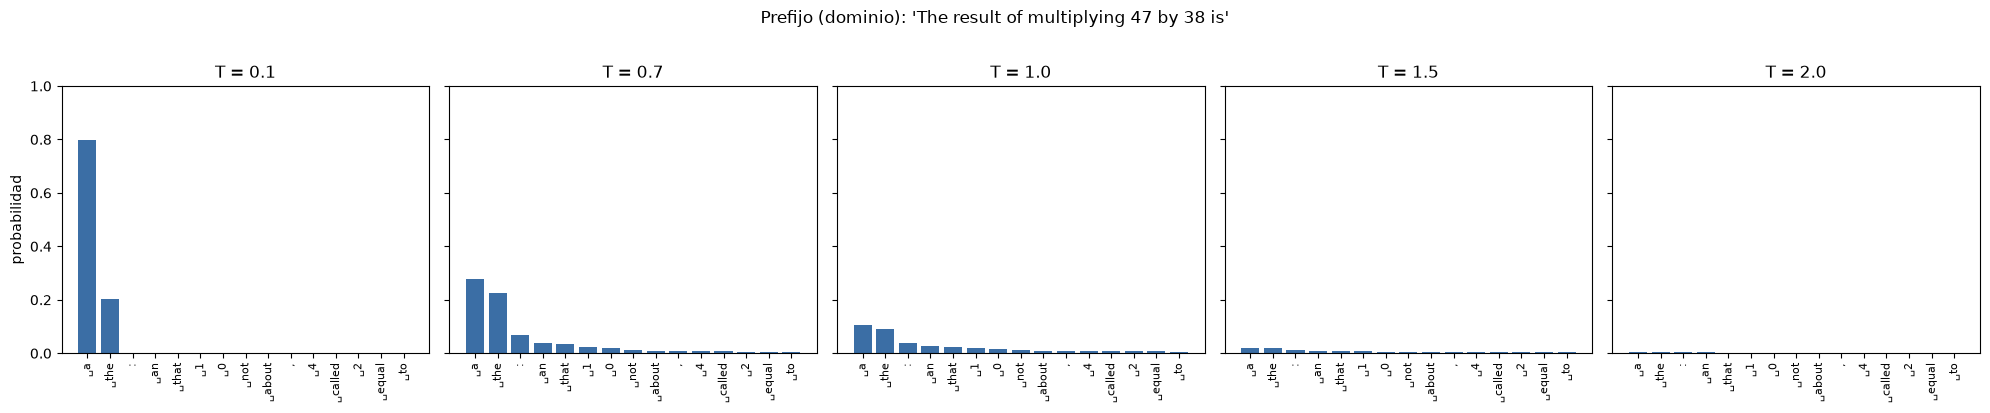

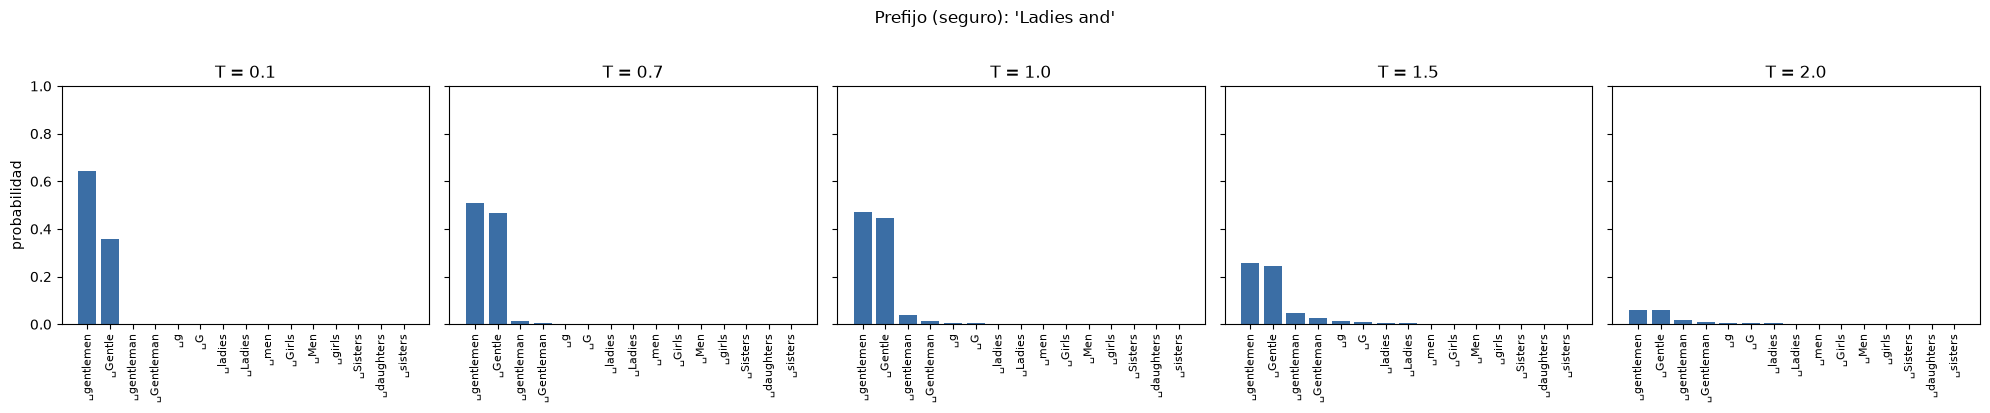

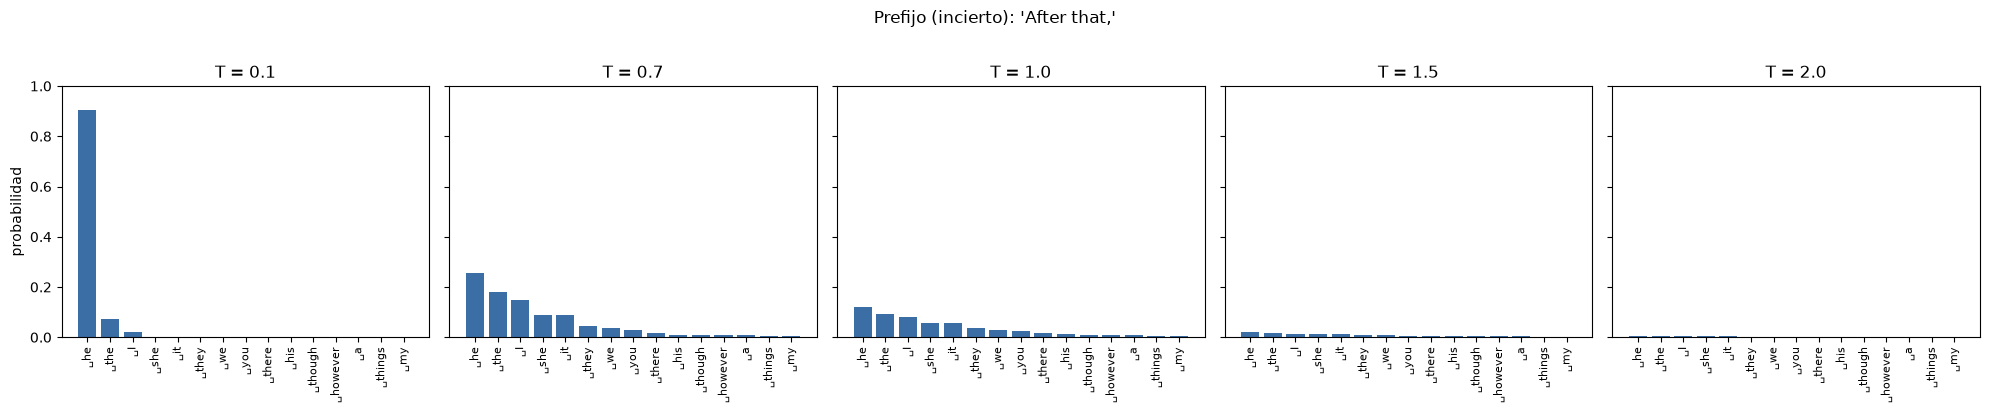

In [4]:
TEMPERATURAS = [0.1, 0.7, 1.0, 1.5, 2.0]

for nombre, pref in PREFIJOS.items():
    logits = LOGITS[pref]
    top15 = np.argsort(logits)[::-1][:15]
    etiquetas = [etiqueta(i) for i in top15]
    fig, ejes = plt.subplots(1, len(TEMPERATURAS), figsize=(20, 4), sharey=True)
    for ax, T in zip(ejes, TEMPERATURAS):
        p = softmax_T(logits, T)
        ax.bar(range(15), p[top15], color="#3b6ea5")
        ax.set_xticks(range(15))
        ax.set_xticklabels(etiquetas, rotation=90, fontsize=8)
        ax.set_title(f"T = {T}")
        ax.set_ylim(0, 1)
    ejes[0].set_ylabel("probabilidad")
    fig.suptitle(f"Prefijo ({nombre}): {pref!r}", y=1.02)
    fig.tight_layout()
    fig.savefig(tl.DIR_FIGURAS / f"p0a_{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()

### 0.a.2 y 0.a.3 — Entropía y tamaño del núcleo (T × prefijo)
Para cada prefijo y cada T: entropía en bits y cuántos tokens acumulan el 90 % de la masa. La comparación entre el prefijo **seguro** y el **incierto** es el punto 3 del taller.

In [5]:
filas = []
for nombre, pref in PREFIJOS.items():
    for T in TEMPERATURAS:
        p = softmax_T(LOGITS[pref], T)
        filas.append({"prefijo": nombre, "T": T, "p_top1": round(float(p.max()), 4),
                      "entropia_bits": round(entropia_bits(p), 3), "nucleo_90": tamano_nucleo(p)})
tabla_0a = pd.DataFrame(filas)
tabla_0a.to_csv(tl.RAIZ / "resultados" / "p0a_tabla.csv", index=False)

for nombre in PREFIJOS:
    print(f"--- {nombre}: {PREFIJOS[nombre]!r}")
    print(tabla_0a[tabla_0a.prefijo == nombre][["T", "p_top1", "entropia_bits", "nucleo_90"]].to_string(index=False))

a = tabla_0a[tabla_0a["T"] == 1.0].set_index("prefijo")
print()
print(f"A T=1.0 -> núcleo del prefijo SEGURO: {a.loc['seguro','nucleo_90']} token(s); "
      f"del INCIERTO: {a.loc['incierto','nucleo_90']} token(s); del de DOMINIO: {a.loc['dominio','nucleo_90']}.")

--- dominio: 'The result of multiplying 47 by 38 is'
  T  p_top1  entropia_bits  nucleo_90
0.1  0.7970          0.729          2
0.7  0.2764          4.756         75
1.0  0.1048          8.158        733
1.5  0.0209         11.900       9826
2.0  0.0059         13.656      21016
--- seguro: 'Ladies and'
  T  p_top1  entropia_bits  nucleo_90
0.1  0.6442          0.939          2
0.7  0.5105          1.153          2
1.0  0.4714          1.678          2
1.5  0.2563          6.973       3668
2.0  0.0615         12.476      16081
--- incierto: 'After that,'
  T  p_top1  entropia_bits  nucleo_90
0.1  0.9060          0.531          1
0.7  0.2564          3.761         10
1.0  0.1206          7.892       2957
1.5  0.0191         13.066      16175
2.0  0.0047         14.329      23393

A T=1.0 -> núcleo del prefijo SEGURO: 2 token(s); del INCIERTO: 2957 token(s); del de DOMINIO: 733.


### Comprobación adicional: ¿importa el token de inicio <|endoftext|>?
GPT-2 se entrenó con documentos separados por el token <|endoftext|> (BOS/EOS, id 50256). Nuestros prefijos van **sin** él, y con contextos muy cortos el modelo a veces se comporta de forma rara. Repetimos la medición **con** ese token delante y comparamos, sobre los tres prefijos elegidos más dos frases hechas. Es solo un diagnóstico: si los números cambian mucho, decidimos juntos si rehacemos 0.a con BOS; si no cambian, queda documentado que el resultado es robusto.

In [6]:
extra = [("pangrama", "The quick brown fox jumps over the lazy"), ("frase_hecha", "Once upon a")]
filas = []
for nombre, pref in list(PREFIJOS.items()) + extra:
    for con_bos in (False, True):
        lg = tl.logits_siguiente_token(tok, model, pref, con_bos=con_bos)
        p = softmax_T(lg, 1.0)
        top = int(np.argmax(p))
        filas.append({"prefijo": nombre, "texto": pref, "con_BOS": con_bos, "token_mas_probable": etiqueta(top),
                      "p_top1": round(float(p[top]), 4), "entropia_bits_T1": round(entropia_bits(p), 3),
                      "nucleo_90_T1": tamano_nucleo(p)})
comparacion_bos = pd.DataFrame(filas)
comparacion_bos.to_csv(tl.RAIZ / "resultados" / "p0a_bos.csv", index=False)
print(comparacion_bos.drop(columns="texto").to_string(index=False))

    prefijo  con_BOS token_mas_probable  p_top1  entropia_bits_T1  nucleo_90_T1
    dominio    False                 ␣a  0.1048             8.158           733
    dominio     True                 ␣a  0.1223             8.406           913
     seguro    False         ␣gentlemen  0.4714             1.678             2
     seguro     True         ␣gentlemen  0.6241             1.513             3
   incierto    False                ␣he  0.1206             7.892          2957
   incierto     True                 ␣I  0.1099             7.575          2479
   pangrama    False                  ,  0.0557             9.291          2001
   pangrama     True                  ,  0.0422             9.418          2013
frase_hecha    False              ␣time  0.1766             8.507          1956
frase_hecha     True              ␣time  0.9919             0.143             1


**Conclusión 0.a (3–5 frases; sin la palabra prohibida del taller).**

Dividir los logits entre T no cambia el orden de los tokens, solo cuánta masa se lleva cada uno. Con T bajo la distribución se concentra (en el prefijo de dominio, la probabilidad del token más probable pasa de 0.105 con T=1.0 a 0.797 con T=0.1) y con T alto se aplana hacia la uniforme (la entropía sube de 8.2 a 13.7 bits entre T=1.0 y T=2.0, con un máximo posible de unos 15.6 bits para 50257 tokens). Por eso el tamaño del núcleo del 90 % no es una constante del parámetro: con T=1.0 son 2 tokens tras «Ladies and», 733 tras el prefijo de dominio y 2957 tras «After that,», y en el prefijo seguro el núcleo salta de 2 a 3668 tokens entre T=1.0 y T=1.5. La medición también depende de cómo se presenta el prefijo: sin el token de inicio de documento, «Once upon a» deja la entropía en 8.5 bits, y con él cae a 0.14 bits (la probabilidad de «time» pasa de 0.18 a 0.99), un hallazgo que conviene tener presente al leer cualquier distribución de GPT-2.

## 0.b — Las tres palancas sobre esa misma distribución
Ahora model.generate(...) con la semilla fijada. Prefijo: el de dominio. Cada generación se registra en resultados.csv.

### 0.b.1 — El interruptor primero: do_sample=False ignora la temperatura
Con do_sample=False el modelo hace **greedy**: en cada paso toma el argmax. La temperatura solo se usa *al muestrear*, así que aquí se acepta sin quejarse **y no actúa** (el estado «aceptado y no actúa» de la Parte 2.a, visto en local). Si en cambio se te olvida poner do_sample=True, temperature=1.5 no hace nada.

In [7]:
PREF_B = PREFIJOS["dominio"]
salidas_b1 = {}
for T in (0.2, 1.5):
    g = tl.generar(tok, model, PREF_B, semilla=SEMILLA, max_new_tokens=30, do_sample=False, temperature=T)
    salidas_b1[T] = g
    tl.registrar_generacion_local("0b", "0b1_dominio", g, {"do_sample": False, "temperature": T}, nota="interruptor: do_sample=False")
    print(f"do_sample=False, temperature={T}\n  -> {g['texto']!r}\n")

print("¿Salida idéntica en los dos casos?", salidas_b1[0.2]["ids"] == salidas_b1[1.5]["ids"])

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


do_sample=False, temperature=0.2
  -> ' a total of 1,847,847,847,847,847,847,847,847,8'

do_sample=False, temperature=1.5
  -> ' a total of 1,847,847,847,847,847,847,847,847,8'

¿Salida idéntica en los dos casos? True


### 0.b.2 — top_k = 1 reproduce greedy
Con top_k=1 solo sobrevive el token más probable, así que aunque muestrees (do_sample=True) el resultado tiene que ser el mismo de greedy. Lo comprobamos de dos formas: (a) cinco corridas con semillas distintas dan los mismos ids que do_sample=False; (b) el primer token generado coincide con el argmax de la distribución de 0.a (no solo con «varias corridas iguales»: se compara contra la distribución).

In [8]:
greedy = tl.generar(tok, model, PREF_B, semilla=SEMILLA, max_new_tokens=30, do_sample=False)
tl.registrar_generacion_local("0b", "0b2_dominio", greedy, {"do_sample": False}, corrida=-1, nota="referencia greedy")

corridas_k1 = []
for c in range(5):
    g = tl.generar(tok, model, PREF_B, semilla=c, max_new_tokens=30, do_sample=True, top_k=1, top_p=1.0, temperature=1.0)
    corridas_k1.append(g)
    tl.registrar_generacion_local("0b", "0b2_dominio", g, {"do_sample": True, "top_k": 1, "top_p": 1.0, "temperature": 1.0}, corrida=c, nota=f"semilla={c}")
    print(f"corrida {c} (semilla {c}): {g['texto']!r}")

print("\nGreedy:", repr(greedy["texto"]))
print("¿Las 5 corridas con top_k=1 == greedy?", all(g["ids"] == greedy["ids"] for g in corridas_k1))

argmax_0a = int(np.argmax(LOGITS[PREF_B]))
print(f"Primer token: argmax de la distribución = {argmax_0a} ({etiqueta(argmax_0a)!r}); "
      f"generado con top_k=1 = {corridas_k1[0]['ids'][0]}; ¿coinciden? {argmax_0a == corridas_k1[0]['ids'][0]}")

corrida 0 (semilla 0): ' a total of 1,847,847,847,847,847,847,847,847,8'
corrida 1 (semilla 1): ' a total of 1,847,847,847,847,847,847,847,847,8'
corrida 2 (semilla 2): ' a total of 1,847,847,847,847,847,847,847,847,8'
corrida 3 (semilla 3): ' a total of 1,847,847,847,847,847,847,847,847,8'
corrida 4 (semilla 4): ' a total of 1,847,847,847,847,847,847,847,847,8'

Greedy: ' a total of 1,847,847,847,847,847,847,847,847,8'
¿Las 5 corridas con top_k=1 == greedy? True
Primer token: argmax de la distribución = 257 ('␣a'); generado con top_k=1 = 257; ¿coinciden? True


### 0.b.3 — Dónde corta cada palanca
Sobre la distribución a T = 1:
- **top_k = 5**: corte de **tamaño fijo**: sobreviven siempre 5 tokens.
- **top_p = 0.9**: corte de **masa fija**: sobreviven los tokens necesarios para acumular 0.9 (pueden ser 1 o 200).

En la figura: azul oscuro = sobrevive a los dos cortes; naranja = solo a top_p; celeste = solo a top_k; gris = a ninguno. Donde el tamaño del núcleo ≠ 5, **los dos conjuntos no coinciden**: eso es la diferencia entre un corte de tamaño fijo y uno de masa fija.

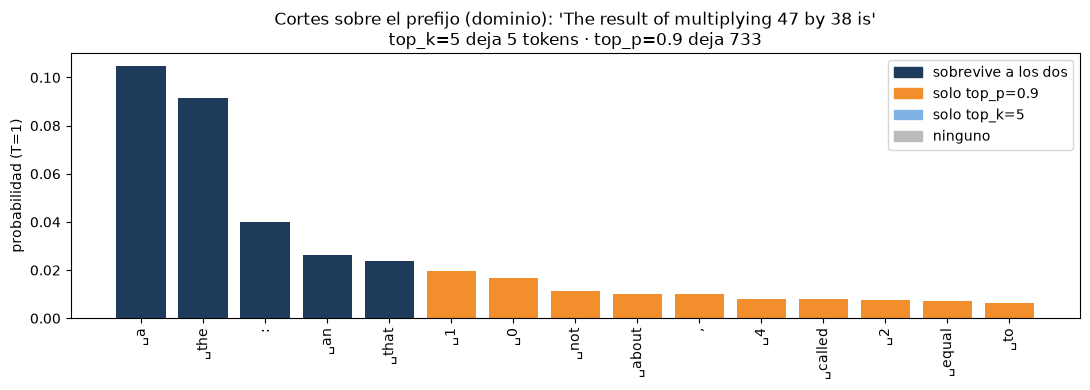

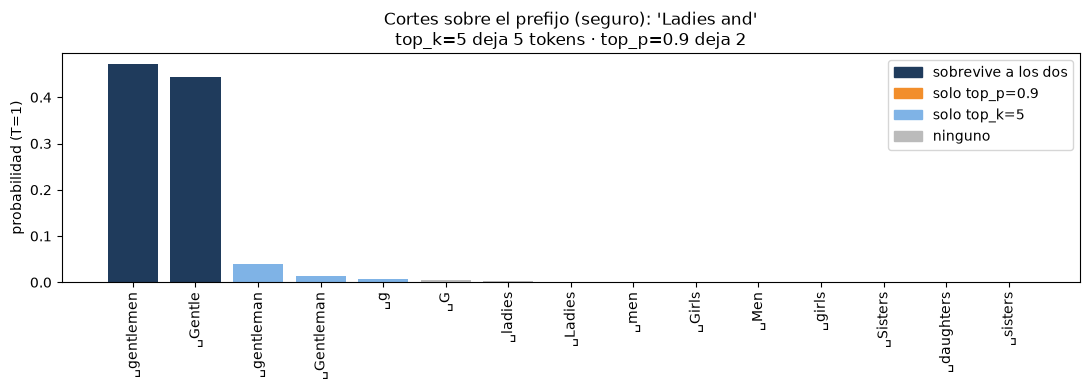

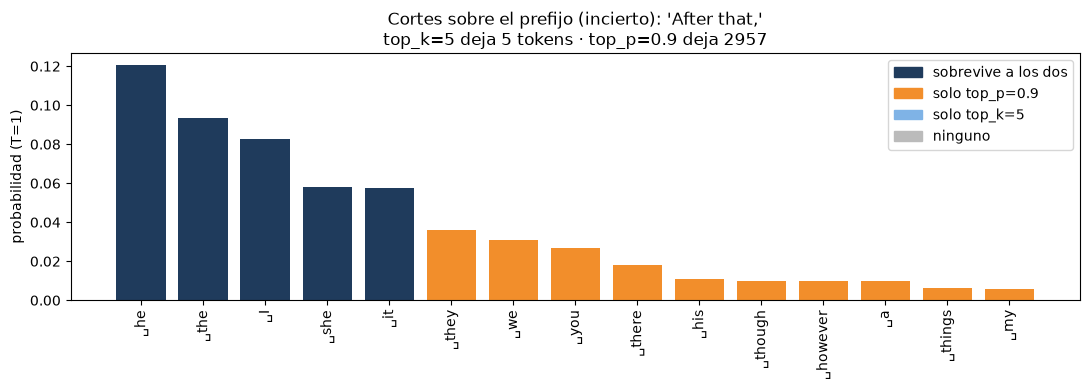

 prefijo  tokens_top_k5  tokens_top_p09  coinciden
 dominio              5             733      False
  seguro              5               2      False
incierto              5            2957      False


In [9]:
from matplotlib.patches import Patch

resumen_cortes = []
for nombre, pref in PREFIJOS.items():
    logits = LOGITS[pref]
    p = softmax_T(logits, 1.0)
    orden = np.argsort(logits)[::-1]
    n_nucleo = tamano_nucleo(p, 0.9)
    top15 = orden[:15]
    color = []
    for rango in range(15):
        en_k = rango < 5
        en_p = rango < n_nucleo
        color.append("#1f3b5c" if (en_k and en_p) else "#f28e2b" if en_p else "#7fb3e6" if en_k else "#bbbbbb")
    fig, ax = plt.subplots(figsize=(11, 4))
    ax.bar(range(15), p[top15], color=color)
    ax.set_xticks(range(15))
    ax.set_xticklabels([etiqueta(i) for i in top15], rotation=90)
    ax.set_ylabel("probabilidad (T=1)")
    ax.set_title(f"Cortes sobre el prefijo ({nombre}): {pref!r}\ntop_k=5 deja 5 tokens · top_p=0.9 deja {n_nucleo}")
    ax.legend(handles=[Patch(color="#1f3b5c", label="sobrevive a los dos"), Patch(color="#f28e2b", label="solo top_p=0.9"),
                       Patch(color="#7fb3e6", label="solo top_k=5"), Patch(color="#bbbbbb", label="ninguno")])
    fig.tight_layout()
    fig.savefig(tl.DIR_FIGURAS / f"p0b_cortes_{nombre}.png", dpi=150, bbox_inches="tight")
    plt.show()
    resumen_cortes.append({"prefijo": nombre, "tokens_top_k5": 5, "tokens_top_p09": n_nucleo, "coinciden": n_nucleo == 5})

cortes = pd.DataFrame(resumen_cortes)
cortes.to_csv(tl.RAIZ / "resultados" / "p0b_cortes.csv", index=False)
print(cortes.to_string(index=False))

### 0.b.4 — Degeneración
Generamos 100 tokens con do_sample=False y pegamos la salida **sin editar**, con dos prefijos: (1) el clásico de los unicornios del artículo de GPT-2 y (2) el prefijo de aritmética. Aparece un **bucle**: el modelo repite la misma frase o el mismo trozo de texto. Ese comportamiento tiene nombre y bibliografía (Holtzman et al., 2020, *The Curious Case of Neural Text Degeneration*): elegir siempre el token más probable no produce texto natural. Medimos el bucle con la fracción de 4-gramas repetidos (0 = variado, 1 = bucle total).

In [10]:
PREF_DEGEN = ("In a shocking finding, scientists discovered a herd of unicorns living in a remote, "
              "previously unexplored valley, in the Andes Mountains.")
g_deg = tl.generar(tok, model, PREF_DEGEN, semilla=SEMILLA, max_new_tokens=100, do_sample=False)
tl.registrar_generacion_local("0b", "0b4_unicornios", g_deg, {"do_sample": False, "max_new_tokens": 100}, nota="degeneracion greedy")

print("SALIDA CRUDA (100 tokens, greedy):")
print(g_deg["texto"])
print()
print(f"Tokens generados: {g_deg['tokens_salida']} | fracción de 4-gramas repetidos: "
      f"{tl.fraccion_ngramas_repetidos(g_deg['ids'], 4):.2f}")

print("\n" + "=" * 60)
g_deg2 = tl.generar(tok, model, PREFIJOS["dominio"], semilla=SEMILLA, max_new_tokens=100, do_sample=False)
tl.registrar_generacion_local("0b", "0b4_aritmetica", g_deg2, {"do_sample": False, "max_new_tokens": 100}, nota="degeneracion greedy, prefijo de dominio")
print(f"SALIDA CRUDA (100 tokens, greedy) con el prefijo {PREFIJOS['dominio']!r}:")
print(g_deg2["texto"])
print()
print(f"Tokens generados: {g_deg2['tokens_salida']} | fracción de 4-gramas repetidos: "
      f"{tl.fraccion_ngramas_repetidos(g_deg2['ids'], 4):.2f}")

SALIDA CRUDA (100 tokens, greedy):


The researchers found that the unicorns were able to survive in the wild for up to 10 years, and that they were able to survive in the wild for up to 10,000 years.

"This is a very exciting discovery," said Dr. David H. Hirsch, a professor of ecology and evolutionary biology at the University of California, Berkeley. "It's a very exciting discovery that we can now say that the unicorns are able to survive in the wild for up to

Tokens generados: 100 | fracción de 4-gramas repetidos: 0.16

SALIDA CRUDA (100 tokens, greedy) con el prefijo 'The result of multiplying 47 by 38 is':
 a total of 1,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847,847

Tokens generados: 100 | fracción de 4-gramas repetidos: 0.93


**Entregable 0.b:** salidas crudas de los cuatro puntos (arriba), figuras con los dos cortes (`figuras/p0b_cortes_*.png`) y comprobación de top_k=1 con sus cinco corridas (arriba).

**0.b.1 — Por qué la salida es idéntica con do_sample=False.** Con do_sample=False, generate toma el argmax de los logits en cada paso, y la temperatura solo interviene cuando se muestrea. Además, dividir todos los logits entre un T positivo no cambia cuál es el mayor, así que ni en teoría podría alterar el argmax. Transformers lo avisa sin fallar: «The following generation flags are not valid and may be ignored: ['temperature']». Es el estado «aceptado y no actúa»: no hubo error y la salida es idéntica con T=0.2 y con T=1.5 (« a total of 1,847,847,847,…»).

**0.b.2 — top_k=1 reproduce greedy.** Las cinco corridas con do_sample=True y top_k=1 (semillas 0 a 4) produjeron exactamente los mismos ids que do_sample=False, y el primer token generado (id 257, «␣a») coincide con el argmax de la distribución de 0.a. No se infiere de la varianza entre corridas: con k=1 sobrevive un solo token, así que sortear entre un único candidato equivale al argmax.

**0.b.3 — Dónde corta cada palanca.** Con top_k=5 sobreviven siempre 5 tokens; con top_p=0.9 sobreviven 733 en el prefijo de dominio, 2 en el seguro y 2957 en el incierto. Los dos conjuntos no coinciden en ninguno de los tres prefijos: en el seguro, k=5 conserva tres tokens que p=0.9 descarta; en el incierto, p=0.9 conserva casi 3000 tokens y k=5 solo cinco. Es la diferencia entre un corte de tamaño fijo y uno de masa fija.

**0.b.4 — Degeneración.** Con greedy y el prefijo de dominio la salida es « a total of 1,847,847,847,…», y a los 100 tokens el 93 % de los 4-gramas están repetidos (en el texto de los unicornios, 0.16). Es la degeneración que describen Holtzman et al. (2020): con decodificación de máxima probabilidad el texto se vuelve repetitivo porque la probabilidad de repetir una frase crece con cada repetición.

## 0.c — El límite del modelo base
Le damos a GPT-2 **la instrucción exacta** que usarán las Partes 1 a 4 (tallerlib.INSTRUCCION + un caso) y pegamos su salida sin editar: una vez con greedy y una con muestreo (T = 0.7). Lo esperado es una continuación que **no obedece** ni resuelve nada; si respondiera bien y con formato, sospecharíamos que cargamos un modelo alineado por error (arriba imprimimos el nombre y el tamaño: 124 M, GPT2LMHeadModel).

In [11]:
caso = next(c for c in tl.cargar_casos("principal") if c["id"] == "M1")
prompt_0c = tl.construir_prompt(caso["enunciado"])
print("PROMPT EXACTO (el mismo de las Partes 1 a 4):")
print(prompt_0c)
print("-" * 60)

g_greedy = tl.generar(tok, model, prompt_0c, semilla=SEMILLA, max_new_tokens=100, do_sample=False)
tl.registrar_generacion_local("0c", caso["id"], g_greedy, {"do_sample": False, "max_new_tokens": 100}, nota="0c greedy")
print("SALIDA CRUDA (greedy, 100 tokens):")
print(g_greedy["texto"])
print("-" * 60)

g_muestreo = tl.generar(tok, model, prompt_0c, semilla=SEMILLA, max_new_tokens=100, do_sample=True, temperature=0.7, top_k=0, top_p=1.0)
tl.registrar_generacion_local("0c", caso["id"], g_muestreo, {"do_sample": True, "temperature": 0.7, "top_k": 0, "top_p": 1.0, "max_new_tokens": 100}, nota="0c muestreo T=0.7")
print("SALIDA CRUDA (T=0.7, 100 tokens):")
print(g_muestreo["texto"])
print("-" * 60)
print("Respuesta esperada del caso:", caso["respuesta_esperada"])

PROMPT EXACTO (el mismo de las Partes 1 a 4):
Solve the arithmetic problem. Reply with the final integer only: no thousands separators, no decimals, no explanation.

Problem: Calculate 43 × 17
Answer:
------------------------------------------------------------
SALIDA CRUDA (greedy, 100 tokens):


The problem is to solve the problem by multiplying the number of digits by the number of digits.

The problem is to solve the problem by multiplying the number of digits by the number of digits.

The problem is to solve the problem by multiplying the number of digits by the number of digits.

The problem is to solve the problem by multiplying the number of digits by the number of digits.

The problem is to solve the problem by multiplying the number of digits by
------------------------------------------------------------
SALIDA CRUDA (T=0.7, 100 tokens):
 No, we cannot find the 43 × 17 problem. We don't need to know the answer to find it. We need to know the answer to find it.

Problem: Solv

**Respuesta 0.c (100–150 palabras):** ¿qué hace GPT-2 en lugar de obedecer y qué tienen los modelos de las otras partes que a éste le falta?

GPT-2 no obedece: trata la instrucción como texto que hay que continuar. En la salida pegada arriba repite «The problem is to solve the problem by multiplying the number of digits by the number of digits» una y otra vez y nunca escribe 731; con T=0.7 inventa otro «Problem:» y sigue. No hay tarea para él, solo un prefijo cuya continuación más probable en su corpus es más texto parecido. Lo que les falta son los pasos posteriores al preentrenamiento: el ajuste por instrucciones, con pares petición–respuesta y una plantilla de chat que marca dónde termina la petición, y la alineación con preferencias humanas, que enseñan «si alguien pide algo, se responde y se para». gpt-5.6-luna, gpt-4o-mini y qwen3:1.7b pasaron por ese entrenamiento; por eso, con el mismo prompt, sí devuelven un entero, aunque no siempre respeten el formato.

_Esta salida es la evidencia de la pregunta 2 de la Parte 5._

## Cierre: 


In [12]:
crudo = pd.read_csv(tl.RUTA_CSV)
p0 = crudo[crudo.parte.isin(["0a", "0b", "0c"])]
print(f"Filas de la Parte 0 en resultados.csv: {len(p0)}   |   costo total: {p0.costo_usd.sum():.2f} USD")
print(p0[["parte", "caso", "corrida", "tokens_entrada", "tokens_salida", "latencia_s", "costo_usd"]].to_string(index=False))

Filas de la Parte 0 en resultados.csv: 12   |   costo total: 0.00 USD
parte           caso  corrida  tokens_entrada  tokens_salida  latencia_s  costo_usd
   0b    0b1_dominio        0             8.0           30.0      0.3487        0.0
   0b    0b1_dominio        0             8.0           30.0      0.3076        0.0
   0b    0b2_dominio       -1             8.0           30.0      0.3190        0.0
   0b    0b2_dominio        0             8.0           30.0      0.3405        0.0
   0b    0b2_dominio        1             8.0           30.0      0.3465        0.0
   0b    0b2_dominio        2             8.0           30.0      0.3325        0.0
   0b    0b2_dominio        3             8.0           30.0      0.3327        0.0
   0b    0b2_dominio        4             8.0           30.0      0.3361        0.0
   0b 0b4_unicornios        0            28.0          100.0      1.0955        0.0
   0b 0b4_aritmetica        0             8.0          100.0      1.0676        0.0
   0c 